In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [4]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target


In [5]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [6]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [7]:
X = df.drop('target', axis=1)
y = df['target']

In [8]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [11]:
# STEP 6: Predict + Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9666666666666667


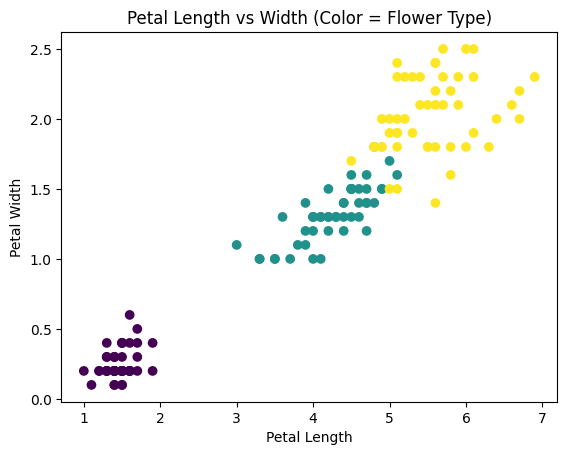

In [12]:
#  VISUALIZATION (IMPORTANT)
# -------------------------------

# Scatter plot: Petal Length vs Petal Width
plt.figure()
plt.scatter(df['petal length (cm)'], df['petal width (cm)'], c=df['target'])
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Petal Length vs Width (Color = Flower Type)')
plt.show()

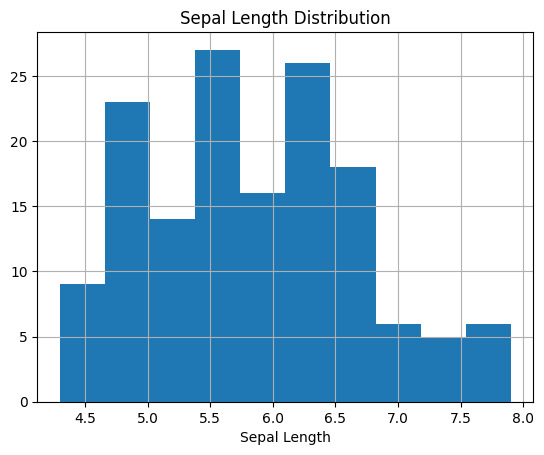

In [13]:
# Histogram: Sepal Length Distribution
plt.figure()
df['sepal length (cm)'].hist()
plt.xlabel('Sepal Length')
plt.title('Sepal Length Distribution')
plt.show()


In [14]:
# Simple Explanation
# -------------------------------
# Scatter Plot:
# Shows how different flowers are separated using petal size

# Histogram:
# Shows how values are distributed (how frequent each range is)

# Model:
# Learns patterns from data and predicts flower type

In [18]:
sl = float(input("Enter Sepal Length: "))
sw = float(input("Enter Sepal Width: "))
pl = float(input("Enter Petal Length: "))
pw = float(input("Enter Petal Width: "))

sample = pd.DataFrame([[sl, sw, pl, pw]], columns=X.columns)

prediction = model.predict(sample)

print("Predicted Flower:", iris.target_names[prediction[0]])

Enter Sepal Length: 5
Enter Sepal Width: 6
Enter Petal Length: 7
Enter Petal Width: 5
Predicted Flower: virginica


**NOW CONVERTING THE ML MODEL INTO A MINI ML APP THAT CLASSIFIES IRIS VARIETY**

In [20]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.3 MB/s eta 0:00:00


In [21]:
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
#ipywidgets → lets you create input boxes & buttons display → shows UI in notebook

In [22]:
sl = widgets.FloatText(description='Sepal Length:')
sw = widgets.FloatText(description='Sepal Width:')
pl = widgets.FloatText(description='Petal Length:')
pw = widgets.FloatText(description='Petal Width:')

In [23]:
button = widgets.Button(description="Predict")

In [24]:
output = widgets.Output()

In [25]:
def on_button_click(b):
    with output:
        output.clear_output()

        sample = pd.DataFrame([[sl.value, sw.value, pl.value, pw.value]], columns=X.columns)

        prediction = model.predict(sample)

        print("Predicted Flower:", iris.target_names[prediction[0]])

In [26]:
#Takes user input
# Converts to DataFrame (same format as training)
# Runs prediction
# Prints result

In [27]:
button.on_click(on_button_click)

In [28]:
display(sl, sw, pl, pw, button, output)

FloatText(value=0.0, description='Sepal Length:')

FloatText(value=0.0, description='Sepal Width:')

FloatText(value=0.0, description='Petal Length:')

FloatText(value=0.0, description='Petal Width:')

Button(description='Predict', style=ButtonStyle())

Output()